# Automated Cursive OCR Dataset Collection

This notebook automates the creation of cursive handwriting datasets from PDF documents.

**Features:**
- Upload PDF files containing cursive handwriting
- Optionally provide transcripts (simple TXT or JSON format)
- Automatic word recognition using the Gemini model
- Word-level bounding box extraction
- JSON dataset output\

Install Dependencies

In [ ]:
!apt-get update -qq && apt-get install -y -qq poppler-utils

!pip install --upgrade \
    torch torchvision torchaudio \
    transformers accelerate \
    einops easydict addict \
    Pillow pdf2image

!pip install --upgrade torchvision transformers pillow einops pdf2image
!apt-get install poppler-utils

!pip install pdf2image einops
!apt-get install -y poppler-utils

print("✅ Dependencies installed")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
✅ Dependencies installed


## Extract Word Bounding Boxes

In [1]:
import os
# os.environ["GOOGLE_API_KEY"] = "PASTE_KEY_HERE"
# os.environ["GOOGLE_API_KEY"] = "555"

In [ ]:
from google.colab import userdata
import os

# This grabs the key from the secure vault on the left
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

print("✅ Key loaded securely from Secrets!")

🤖 Initializing gemini-3-pro-preview...
📖 Reading PDF...
✅ Loaded Page 2
   ...Analyzing image with models/gemini-3-pro-preview...
✅ Extraction Complete! Found 96 words.
💾 Tool saved to: /content/handwriting_tool.html
💾 Raw Data saved to: /content/bbox_data/page_2_data.json
🖼️ Visualization saved to: /content/bbox_data/page_2_visualized.jpg

--- Previewing Result (Scaled Down) ---


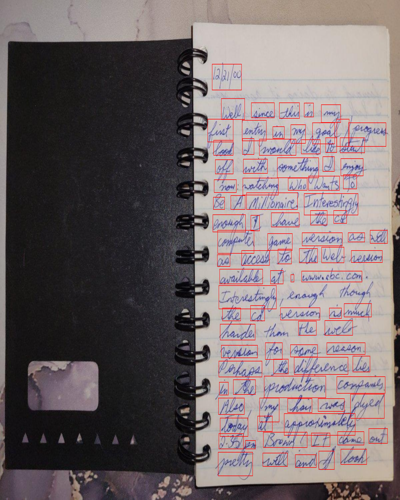

In [ ]:
# 1. Install dependencies
!pip install -q -U google-generativeai pdf2image

import google.generativeai as genai
from google.colab import userdata
from pdf2image import convert_from_path
from PIL import Image, ImageDraw
import os
import json

# --- CONFIGURATION ---
PDF_PATH = "/content/test_document.pdf"
OUTPUT_DIR = "/content/bbox_data"
HTML_OUTPUT_PATH = "/content/handwriting_tool.html"

# --- PAGE RANGE SETTINGS ---
# Python uses 0-based indexing (Page 1 is index 0).
# The range is inclusive of START, exclusive of END.
START_PAGE_INDEX = 0  # Start at Page 1
END_PAGE_INDEX = 3    # Stop before Page 4 (Processes pages 0, 1, and 2)

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- SETUP API KEY ---
try:
    api_key = userdata.get('GOOGLE_API_KEY')
except:
    api_key = os.environ.get("GOOGLE_API_KEY")

if not api_key:
    raise ValueError("❌ API Key not found! Please set 'GOOGLE_API_KEY' in Secrets or os.environ.")

genai.configure(api_key=api_key)

# --- MODEL SETUP ---
# We first try 'gemini-3-pro-preview'. If that fails, we fallback to 'gemini-1.5-pro'.
target_model = "gemini-3-pro-preview"

print(f"🤖 Initializing {target_model}...")
model = genai.GenerativeModel(
    model_name=target_model,
    generation_config={"response_mime_type": "application/json"}
)

# --- HTML TEMPLATE ---
HTML_TEMPLATE = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Handwriting Stroke Capture - Gemini 3 Powered</title>
    <script src="https://unpkg.com/react@17/umd/react.development.js"></script>
    <script src="https://unpkg.com/react-dom@17/umd/react-dom.development.js"></script>
    <script src="https://unpkg.com/babel-standalone@6/babel.min.js"></script>
    <style>
        body {{ font-family: Arial, sans-serif; }}
        .container {{ max-width: 1200px; margin: 0 auto; padding: 20px; }}
        button {{ cursor: pointer; }}
        input[type="range"] {{ width: 100%; }}
        canvas {{ border: 1px solid #ccc; }}
    </style>
</head>
<body>
    <div id="root"></div>
    <script type="text/babel">
        const SAMPLING_INTERVAL = 2;

        const Button = ({{ onClick, children }}) => (
            <button
                onClick={{onClick}}
                style={{{{
                    padding: '8px 16px',
                    backgroundColor: '#2D3748',
                    color: 'white',
                    border: 'none',
                    borderRadius: '4px',
                    marginRight: '8px'
                }}}}
            >
                {{children}}
            </button>
        );

        const Input = ({{ type, accept, onChange, value, placeholder, style, min, max, id }}) => (
            <input
                type={{type}}
                accept={{accept}}
                onChange={{onChange}}
                value={{value}}
                placeholder={{placeholder}}
                style={{{{ ...style, padding: '4px', marginBottom: '8px' }}}}
                min={{min}}
                max={{max}}
                id={{id}}
            />
        );

        const Textarea = ({{ value, readOnly, style, placeholder }}) => (
            <textarea
                value={{value}}
                readOnly={{readOnly}}
                style={{{{ ...style, padding: '4px', width: '100%', height: '200px' }}}}
                placeholder={{placeholder}}
            />
        );

        const Label = ({{ htmlFor, children }}) => (
            <label htmlFor={{htmlFor}} style={{{{ display: 'block', marginBottom: '4px' }}}}>
                {{children}}
            </label>
        );

        const Slider = ({{ id, min, max, step, value, onChange }}) => (
            <input
                id={{id}}
                type="range"
                min={{min}}
                max={{max}}
                step={{step}}
                value={{value}}
                onChange={{onChange}}
                style={{{{ width: '100%' }}}}
            />
        );

        const ErrorMessage = ({{ message }}) => (
            <div style={{{{ backgroundColor: '#FEE2E2', border: '1px solid #F87171', color: '#B91C1C', padding: '8px', borderRadius: '4px', marginBottom: '16px' }}}}>
                <span>{{message}}</span>
            </div>
        );

        const HandwritingStrokeCapture = () => {{
            const [strokes, setStrokes] = React.useState([]);
            const [currentStroke, setCurrentStroke] = React.useState([]);
            const [backgroundImage, setBackgroundImage] = React.useState(null);
            const [imagePosition, setImagePosition] = React.useState({{ x: 0, y: 0 }});
            const [imageScale, setImageScale] = React.useState(1);
            const [isDrawing, setIsDrawing] = React.useState(false);
            const [exportedData, setExportedData] = React.useState('');
            const [author, setAuthor] = React.useState('');
            const [asciiSequence, setAsciiSequence] = React.useState('');
            const [errorMessage, setErrorMessage] = React.useState('');
            const [dataset, setDataset] = React.useState([]);
            const [wordBank, setWordBank] = React.useState([]);
            const [currentPrompt, setCurrentPrompt] = React.useState('');
            const [wordCount, setWordCount] = React.useState(1);
            const [samplingMode, setSamplingMode] = React.useState('random');
            const [startIndex, setStartIndex] = React.useState(0);
            const [currentIndex, setCurrentIndex] = React.useState(0);
            const [displayIndex, setDisplayIndex] = React.useState(0);

            const canvasRef = React.useRef(null);
            const lastPointRef = React.useRef(null);
            const lastSampledPointRef = React.useRef(null);

            const drawStrokes = React.useCallback(() => {{
                const canvas = canvasRef.current;
                if (!canvas) return;
                const ctx = canvas.getContext('2d');
                ctx.clearRect(0, 0, canvas.width, canvas.height);

                if (backgroundImage) {{
                    ctx.save();
                    ctx.translate(imagePosition.x, imagePosition.y);
                    ctx.scale(imageScale, imageScale);
                    ctx.drawImage(backgroundImage, 0, 0);
                    ctx.restore();
                }}

                ctx.strokeStyle = 'rgba(0, 0, 0, 0.5)';
                ctx.lineWidth = 1;
                ctx.setLineDash([5, 5]);
                ctx.beginPath();
                ctx.moveTo(0, canvas.height / 3);
                ctx.lineTo(canvas.width, canvas.height / 3);
                ctx.moveTo(0, 2 * canvas.height / 3);
                ctx.lineTo(canvas.width, 2 * canvas.height / 3);
                ctx.stroke();
                ctx.setLineDash([]);

                ctx.strokeStyle = '#2F4F4F';
                ctx.lineWidth = 2;
                strokes.forEach(stroke => {{
                    if (stroke.length > 0) {{
                        ctx.beginPath();
                        ctx.moveTo(stroke[0][0], stroke[0][1]);
                        stroke.forEach(point => {{
                            if (point[2] === 1) {{
                                ctx.lineTo(point[0], point[1]);
                            }} else {{
                                ctx.moveTo(point[0], point[1]);
                            }}
                        }});
                        ctx.stroke();
                    }}
                }});

                if (currentStroke.length > 0) {{
                    ctx.beginPath();
                    ctx.moveTo(currentStroke[0][0], currentStroke[0][1]);
                    currentStroke.forEach(point => {{
                        if (point[2] === 1) {{
                            ctx.lineTo(point[0], point[1]);
                        }} else {{
                            ctx.moveTo(point[0], point[1]);
                        }}
                    }});
                    ctx.stroke();
                }}
            }}, [strokes, currentStroke, backgroundImage, imagePosition, imageScale]);

            React.useEffect(() => {{
                drawStrokes();
            }}, [drawStrokes]);

            const startDrawing = (e) => {{
                const canvas = canvasRef.current;
                const rect = canvas.getBoundingClientRect();
                const x = e.clientX - rect.left;
                const y = e.clientY - rect.top;
                setCurrentStroke([[x, y, 1]]);
                lastPointRef.current = [x, y];
                lastSampledPointRef.current = [x, y];
                setIsDrawing(true);
            }};

            const draw = (e) => {{
                if (!isDrawing) return;
                const canvas = canvasRef.current;
                const ctx = canvas.getContext('2d');
                const rect = canvas.getBoundingClientRect();
                const x = e.clientX - rect.left;
                const y = e.clientY - rect.top;

                ctx.strokeStyle = '#2F4F4F';
                ctx.lineWidth = 2;
                ctx.beginPath();
                ctx.moveTo(lastPointRef.current[0], lastPointRef.current[1]);
                ctx.lineTo(x, y);
                ctx.stroke();

                const dx = x - lastSampledPointRef.current[0];
                const dy = y - lastSampledPointRef.current[1];
                const distance = Math.sqrt(dx * dx + dy * dy);

                if (distance >= SAMPLING_INTERVAL) {{
                    setCurrentStroke(prev => [...prev, [x, y, 1]]);
                    lastSampledPointRef.current = [x, y];
                }}

                lastPointRef.current = [x, y];
            }};

            const endDrawing = () => {{
                if (currentStroke.length > 0) {{
                    setStrokes(prev => [...prev, [...currentStroke, [currentStroke[currentStroke.length - 1][0], currentStroke[currentStroke.length - 1][1], 0]]]);
                    setCurrentStroke([]);
                }}
                setIsDrawing(false);
                lastPointRef.current = null;
                lastSampledPointRef.current = null;
            }};

            const generateEntry = () => {{
                if (!author.trim()) {{
                    setErrorMessage("Please enter an author name.");
                    return null;
                }}
                if (!asciiSequence.trim()) {{
                    setErrorMessage("Please enter an ASCII sequence.");
                    return null;
                }}
                if (strokes.length === 0) {{
                    setErrorMessage("Please draw at least one stroke before adding to dataset.");
                    return null;
                }}

                let allPoints = strokes.flat();
                const canvas = canvasRef.current;
                const aspectRatio = canvas.width / canvas.height;
                const normalizedPoints = allPoints.map(point => [
                    parseFloat((point[0] / canvas.width).toFixed(4)),
                    parseFloat((point[1] / canvas.height).toFixed(4)),
                    point[2]
                ]);

                return {{
                    metadata: {{author: author.trim(), asciiSequence: asciiSequence.trim(), pointCount: allPoints.length, strokeCount: strokes.length, aspectRatio}},
                    points: normalizedPoints
                }};
            }};

            const addToDataset = () => {{
                const entry = generateEntry();
                if (entry) {{
                    setDataset(prev => [...prev, entry]);
                    setStrokes([]);
                    setAsciiSequence('');
                    setErrorMessage('');
                    drawStrokes();
                    return true; // Entry successfully added
                }}
                return false; // Entry not added due to error
            }};

            const exportDataset = () => {{
                if (dataset.length === 0) {{
                    setErrorMessage("The dataset is empty. Add some entries before exporting.");
                    return;
                }}
                const jsonString = JSON.stringify(dataset);
                setExportedData(jsonString);
            }};

            const handleImageUpload = (e) => {{
                const file = e.target.files[0];
                if (file) {{
                    const reader = new FileReader();
                    reader.onload = (event) => {{
                        const img = new Image();
                        img.onload = () => {{
                            setBackgroundImage(img);
                            setImagePosition({{ x: 0, y: 0 }});
                            setImageScale(1);
                            setAsciiSequence(''); // Clear ASCII box when an image is uploaded
                        }};
                        img.src = event.target.result;
                    }};
                    reader.readAsDataURL(file);
                }}
            }};

            const handleImageMove = (direction) => {{
                const step = 10;
                setImagePosition(prev => {{
                    switch (direction) {{
                        case 'up': return {{ ...prev, y: prev.y - step }};
                        case 'down': return {{ ...prev, y: prev.y + step }};
                        case 'left': return {{ ...prev, x: prev.x - step }};
                        case 'right': return {{ ...prev, x: prev.x + step }};
                        default: return prev;
                    }}
                }});
            }};

            const clearAll = () => {{
                setStrokes([]);
                setCurrentStroke([]);
                setErrorMessage('');
                setBackgroundImage(null); // Clear the uploaded image
                setImagePosition({{ x: 0, y: 0 }}); // Reset image position
                setImageScale(1); // Reset image scale
                if (samplingMode === 'random') {{
                    generatePrompt();
                }}
                drawStrokes();
            }};

            const undo = () => {{
                setStrokes(prev => prev.slice(0, -1));
            }};

            const loadWordBank = () => {{
                const words = {word_bank_json};
                setWordBank(words);
            }};

            const generatePrompt = () => {{
                if (wordBank.length === 0) return;

                    let prompt;
                    if (samplingMode === 'random') {{
                        prompt = Array(wordCount).fill().map(() => wordBank[Math.floor(Math.random() * wordBank.length)]).join(' ');
                        setCurrentPrompt(prompt);
                    }} else {{
                        prompt = Array(wordCount).fill().map(() => {{
                            const word = wordBank[currentIndex];

                            setCurrentIndex((prevIndex) => {{
                                const newIndex = (prevIndex + 1) % wordBank.length;
                                setDisplayIndex(newIndex);
                                return newIndex;
                            }});

                            return word;
                        }}).join(' ');
                        setCurrentPrompt(prompt);
                    }}
                    if (samplingMode === 'random') {{
                        setCurrentPrompt(prompt);
                    }}
                setAsciiSequence(prompt); // Populate ASCII box with the prompt
            }};

            React.useEffect(() => {{
                loadWordBank();
            }}, []);

            React.useEffect(() => {{
                if (samplingMode === 'random') {{
                    generatePrompt();
                }} else if (wordBank.length > 0) {{
                // For ordered mode, generate prompt once when wordBank is loaded
                    generatePrompt();
                }}
            }}, [samplingMode, wordCount, wordBank]);


            return (
                <div className="container">
                    <h2 style={{{{ fontSize: '24px', fontWeight: 'bold', marginBottom: '16px' }}}}>Handwriting Stroke Capture</h2>
                    <p style={{{{ fontSize: '14px', color: '#4B5563', marginBottom: '16px' }}}}>
                        Instructions: Upload an image, trace the writing, enter author and ASCII sequence, then add to dataset. Export when finished.
                    </p>
                    {{errorMessage && <ErrorMessage message={{errorMessage}} />}}
                    <Input
                        type="file"
                        accept="image/*"
                        onChange={{handleImageUpload}}
                        style={{{{ marginBottom: '16px' }}}}
                    />
                    <div style={{{{ marginBottom: '16px' }}}}>
                        <Label htmlFor="word-count">Number of Words in Prompt</Label>
                        <Input
                            id="word-count"
                            type="number"
                            min="1"
                            max="10"
                            value={{wordCount}}
                            onChange={{(e) => {{
                                const newWordCount = parseInt(e.target.value);
                                setWordCount(newWordCount);
                                 // Generate a new prompt only for random mode
                                 // or if it's the initial load for ordered mode
                                setTimeout(() => generatePrompt(), 0);
                            }}}}
                        />
                    </div>
                    {{currentPrompt && (
                        <div style={{{{
                            marginBottom: '16px'
                        }}}}>
                            {{currentPrompt}}
                        </div>
                    )}}
                    <canvas
                        ref={{canvasRef}}
                        width={{1200}}
                        height={{200}}
                        onMouseDown={{startDrawing}}
                        onMouseMove={{draw}}
                        onMouseUp={{endDrawing}}
                        onMouseOut={{endDrawing}}
                        style={{{{ border: '1px solid #CBD5E0', cursor: 'crosshair', marginBottom: '16px', maxWidth: '100%' }}}}
                    />

                    <div style={{{{ marginBottom: '16px' }}}}>
                        <Label htmlFor="sampling-mode">Sampling Mode</Label>
                        <div style={{{{ display: 'flex', alignItems: 'center' }}}}>
                            <Input
                                id="sampling-mode"
                                type="checkbox"
                                checked={{samplingMode === 'ordered'}}
                                onChange={{(e) => {{
                                    setSamplingMode(e.target.checked ? 'ordered' : 'random');
                                    setCurrentIndex(startIndex);
                                }}}}

                                style={{{{ marginRight: '8px' }}}}
                            />
                            <span>Ordered</span>
                        </div>
                    </div>
                    {{samplingMode === 'ordered' && (
                        <div style={{{{ marginBottom: '16px' }}}}>

                            <Label htmlFor="start-index" style={{{{ marginRight: '8px' }}}}>
                            {{`Word Bank Index (current: ${{displayIndex}}/${{wordBank.length}})`}}
                            </Label>
                            <Input
                                id="start-index"
                                type="number"
                                min="1"
                                max={{wordBank.length}}
                                value={{startIndex+1}}
                                onChange={{(e) => {{
                                    const newIndex = Math.max(0, Math.min(parseInt(e.target.value) - 1, wordBank.length - 1));
                                    setStartIndex(newIndex);
                                    setCurrentIndex(newIndex);
                                    setDisplayIndex(newIndex);
                                }}}}

                            />
                        </div>
                    )}}

                    <div style={{{{ marginBottom: '16px' }}}}>
                        <p style={{{{ fontSize: '14px', color: '#4B5563', marginBottom: '8px' }}}}>Image Positioning Controls:</p>
                        <div style={{{{ display: 'grid', gridTemplateColumns: 'repeat(3, 1fr)', gap: '8px', marginBottom: '8px' }}}}>
                            <Button onClick={{() => handleImageMove('up')}}>↑</Button>
                            <Button onClick={{() => handleImageMove('down')}}>↓</Button>
                            <Button onClick={{() => handleImageMove('left')}}>←</Button>
                            <Button onClick={{() => handleImageMove('right')}}>→</Button>
                        </div>
                        <div>
                            <Label htmlFor="scale-slider">Image Scale</Label>
                            <Slider
                                id="scale-slider"
                                min={{0.1}}
                                max={{2}}
                                step={{0.1}}
                                value={{imageScale}}
                                onChange={{(e) => setImageScale(parseFloat(e.target.value))}}
                            />
                        </div>
                    </div>
                    <div style={{{{ display: 'grid', gridTemplateColumns: '1fr 1fr', gap: '16px', marginBottom: '16px' }}}}>
                        <div>
                            <Label htmlFor="author-input">Author</Label>
                            <Input
                                id="author-input"
                                value={{author}}
                                onChange={{(e) => setAuthor(e.target.value)}}
                                placeholder="Enter author name"
                            />
                        </div>
                        <div>
                            <Label htmlFor="ascii-input">ASCII Sequence</Label>
                            <Input
                                id="ascii-input"
                                value={{asciiSequence}}
                                onChange={{(e) => setAsciiSequence(e.target.value)}}
                                placeholder="Enter ASCII sequence"
                            />
                        </div>
                    </div>


                    <div style={{{{ display: 'flex', flexDirection: 'column', gap: '16px', marginBottom: '16px' }}}}>
                        <div style={{{{ display: 'flex', justifyContent: 'space-between', alignItems: 'center' }}}}>
                            <Button onClick={{() => {{ clearAll(); }}}}>Clear All</Button>
                            <Button onClick={{undo}}>Undo</Button>
                            {{samplingMode === 'ordered' && (
                                <Button onClick={{generatePrompt}}>Next Word</Button>
                            )}}
                            <Button onClick={{() => {{
                                const success = addToDataset();
                                if (success && samplingMode === 'ordered') {{
                                    setDisplayIndex((currentIndex + 1) % wordBank.length);
                                    generatePrompt();
                                }} else if (success && samplingMode === 'random') {{
                                    generatePrompt();
                                }}
                            }}}}>Add to Dataset</Button>
                        </div>
                        <div style={{{{ display: 'flex', justifyContent: 'space-between', alignItems: 'center' }}}}>
                            <Button onClick={{exportDataset}}>Export Dataset</Button>
                            <span style={{{{ fontSize: '14px', color: '#4B5563' }}}}>
                                Dataset size: {{dataset.length}} entries
                            </span>
                        </div>
                    </div>

                    {{exportedData && (
                        <Textarea
                            value={{exportedData}}
                            readOnly
                            placeholder="Exported dataset will appear here"
                        />
                    )}}
                </div>
            );
        }};

        ReactDOM.render(<HandwritingStrokeCapture />, document.getElementById('root'));
    </script>
</body>
</html>
"""

def extract_words_and_boxes(pil_image):
    """Sends image to Gemini and requests JSON list of words + boxes."""
    print(f"   ...Analyzing image with {model.model_name}...")

    prompt = """
    Task: Perform Word-Level OCR with Bounding Boxes.

    Instructions:
    1. Identify every single word in the image.
    2. For each word, provide the text and its bounding box.
    3. Format the bounding box as [ymin, xmin, ymax, xmax].
    4. Normalize coordinates to a scale of 0 to 1000 (where 1000 is image height/width).
    5. Return a raw JSON list of objects.

    JSON Schema:
    [
      {"text": "Word1", "box_2d": [ymin, xmin, ymax, xmax]},
      {"text": "Word2", "box_2d": [ymin, xmin, ymax, xmax]}
    ]
    """

    response = model.generate_content([prompt, pil_image])
    return json.loads(response.text)

def draw_boxes_on_image(pil_image, word_data):
    """Helper to visualize the result."""
    draw = ImageDraw.Draw(pil_image)
    width, height = pil_image.size

    for item in word_data:
        box = item.get("box_2d")
        if box:
            ymin, xmin, ymax, xmax = box
            # Convert normalized 0-1000 to pixels
            left = (xmin / 1000) * width
            top = (ymin / 1000) * height
            right = (xmax / 1000) * width
            bottom = (ymax / 1000) * height
            draw.rectangle([left, top, right, bottom], outline="red", width=2)

    return pil_image

# --- MAIN EXECUTION ---

if not os.path.exists(PDF_PATH):
    print(f"❌ Error: {PDF_PATH} not found. Please upload the PDF.")
else:
    print(f"📖 Reading PDF...")
    images = convert_from_path(PDF_PATH)
    total_pages = len(images)
    print(f"📄 PDF has {total_pages} pages.")

    # Ensure we don't go out of bounds
    end_index = min(total_pages, END_PAGE_INDEX)

    # Master list to hold words from ALL pages
    master_word_list = []

    print(f"🚀 Starting processing from page {START_PAGE_INDEX + 1} to {end_index}...")

    # --- LOOP THROUGH PAGES ---
    for i in range(START_PAGE_INDEX, end_index):
        current_page_num = i + 1
        print(f"\n--- Processing Page {current_page_num} ---")

        page_image = images[i]

        try:
            # 1. Extract Data (with fallback logic)
            try:
                word_data = extract_words_and_boxes(page_image)
            except Exception as e:
                if "404" in str(e) and "models/" in str(e):
                    print(f"⚠️ Model {target_model} not found. Falling back to 'gemini-1.5-pro'...")
                    model = genai.GenerativeModel("gemini-1.5-pro", generation_config={"response_mime_type": "application/json"})
                    word_data = extract_words_and_boxes(page_image)
                else:
                    raise e

            count = len(word_data)
            print(f"✅ Page {current_page_num}: Found {count} words.")

            # 2. Aggregate Words
            page_words = [item.get("text", "") for item in word_data]
            master_word_list.extend(page_words) # Add to the master list

            # 3. Save Individual Page Visuals (Optional debug step)
            visual_path = os.path.join(OUTPUT_DIR, f"page_{current_page_num}_visualized.jpg")
            annotated_img = draw_boxes_on_image(page_image.copy(), word_data)
            annotated_img.save(visual_path)
            print(f"🖼️ Saved visual to: {visual_path}")

            # 4. Save Individual Page JSON (Backup)
            json_path = os.path.join(OUTPUT_DIR, f"page_{current_page_num}_data.json")
            with open(json_path, "w") as f:
                json.dump(word_data, f, indent=4)

        except Exception as e:
            print(f"❌ Error on Page {current_page_num}: {e}")
            import traceback
            traceback.print_exc()
            # We continue to the next page even if this one fails

    # --- FINAL GENERATION ---
    print(f"\n✨ Processing Complete! Total words collected: {len(master_word_list)}")

    if len(master_word_list) > 0:
        # Serialize the master list
        word_bank_json = json.dumps(master_word_list)

        # Inject into HTML
        final_html = HTML_TEMPLATE.format(
            word_bank_json=word_bank_json,
            # The following are just passed through to fill the React placeholders
            errorMessage="{errorMessage}",
            wordCount="{wordCount}",
            currentPrompt="{currentPrompt}",
            canvasRef="{canvasRef}",
            displayIndex="{displayIndex}",
            wordBank="{wordBank}",
            startIndex="{startIndex}",
            samplingMode="{samplingMode}",
            imageScale="{imageScale}",
            author="{author}",
            asciiSequence="{asciiSequence}",
            dataset="{dataset}",
            exportedData="{exportedData}",
            handleImageUpload="{handleImageUpload}",
            startDrawing="{startDrawing}",
            draw="{draw}",
            endDrawing="{endDrawing}",
            undo="{undo}",
            generatePrompt="{generatePrompt}",
            exportDataset="{exportDataset}",
            onClick="{onClick}",
            children="{children}",
            type="{type}",
            accept="{accept}",
            onChange="{onChange}",
            value="{value}",
            placeholder="{placeholder}",
            style="{style}",
            min="{min}",
            max="{max}",
            id="{id}",
            htmlFor="{htmlFor}",
            step="{step}",
            message="{message}"
        )

        # Save HTML
        with open(HTML_OUTPUT_PATH, "w") as f:
            f.write(final_html)
        print(f"💾 Tool saved to: {HTML_OUTPUT_PATH}")
        print("✅ You can now download the HTML file.")
    else:
        print("⚠️ No words were extracted from the selected range.")

## Build JSON Dataset


In [ ]:
from google.colab import drive
import datetime
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Create a timestamp so you don't overwrite old backups
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
backup_name = f"colab_backup_{timestamp}.zip"
destination_path = f"/content/drive/MyDrive/{backup_name}"

print(f"Backing up workspace to: {destination_path}")

# 3. Zip the contents of /content/
# -r: recursive (include subfolders)
# -x: exclude specific folders (crucial to avoid infinite loops with Drive)
!zip -r "{destination_path}" /content/ \
    -x "/content/drive/*" \
    -x "/content/sample_data/*" \
    -x "/content/.config/*"

print(f"✅ Backup complete! File saved as '{backup_name}' in your Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Backing up workspace to: /content/drive/MyDrive/colab_backup_2025-11-21_04-58.zip
  adding: content/ (stored 0%)
  adding: content/test_document.pdf (deflated 1%)
  adding: content/handwriting_dataset_processed.json (deflated 78%)
  adding: content/bbox_data/ (stored 0%)
  adding: content/bbox_data/page_2_visualized.jpg (deflated 3%)
  adding: content/bbox_data/page_2_data.json (deflated 88%)
  adding: content/handwriting_tool.html (deflated 79%)
  adding: content/.ipynb_checkpoints/ (stored 0%)
  adding: content/handwriting_dataset_precise.json (deflated 93%)
✅ Backup complete! File saved as 'colab_backup_2025-11-21_04-58.zip' in your Google Drive.


## Step 8: Verify the accuracy

In [ ]:
import json
import cv2
import numpy as np
from pdf2image import convert_from_path
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
PDF_PATH = "/content/test_document.pdf"
# Point to the NEW full trace dataset
JSON_DATASET_PATH = "/content/handwriting_dataset_full_trace.json"
PAGE_INDEX = 1

print("🖼️ Loading...")
images = convert_from_path(PDF_PATH)
img = np.array(images[PAGE_INDEX])
h, w, _ = img.shape

with open(JSON_DATASET_PATH, 'r') as f:
    data = json.load(f)

print(f"🎨 Painting {len(data)} words...")

for entry in data:
    points = entry['points']

    # Loop through points
    for i in range(len(points) - 1):
        p1 = points[i]
        p2 = points[i+1]

        # Logic: We draw a line from P1 to P2 ONLY IF P1 is "Pen Down" (1).
        # If P1 is "Pen Up" (0), it means we are jumping to a new letter,
        # so we do NOT draw a line.
        if p1[2] == 1:
            x1, y1 = int(p1[0] * w), int(p1[1] * h)
            x2, y2 = int(p2[0] * w), int(p2[1] * h)

            cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 1)

plt.figure(figsize=(20, 25))
plt.imshow(img)
plt.axis('off')
plt.title("Full Multi-Character Trace")
plt.show()

🖼️ Loading...


FileNotFoundError: [Errno 2] No such file or directory: '/content/handwriting_dataset_full_trace.json'

## Optional: View Sample Words

Visualize a few extracted words with their bounding boxes.

In [ ]:
from PIL import ImageDraw, ImageFont
import matplotlib.pyplot as plt

def visualize_word_bbox(image, word_data, title=""):
    """Draw bounding box on image."""
    img_copy = image.copy()
    draw = ImageDraw.Draw(img_copy)

    bbox = word_data["bbox"]
    word = word_data["word"]

    if bbox:
        # Draw rectangle
        draw.rectangle(bbox, outline="red", width=3)

        # Draw label
        draw.text((bbox[0], bbox[1] - 20), word, fill="red")

    plt.figure(figsize=(12, 8))
    plt.imshow(img_copy)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Show first 3 words from first page
if all_word_data:
    first_page = list(all_word_data.keys())[0]
    page_idx = int(first_page) - 1
    image = pdf_images[page_idx]

    words_to_show = all_word_data[first_page][:3]

    for i, word_data in enumerate(words_to_show):
        visualize_word_bbox(image, word_data, f"Word {i+1}: '{word_data['word']}'")
else:
    print("No word data to visualize")